Carregando dados de métricas de 'metrics.csv'...
Dados de métricas somados e preparados.
Momento de início (fixo) do processamento: 2025-10-23 14:26:10.920970-03:00

Sucesso! O gráfico combinado foi salvo como 'grafico_recursos_edge_combinado.png'


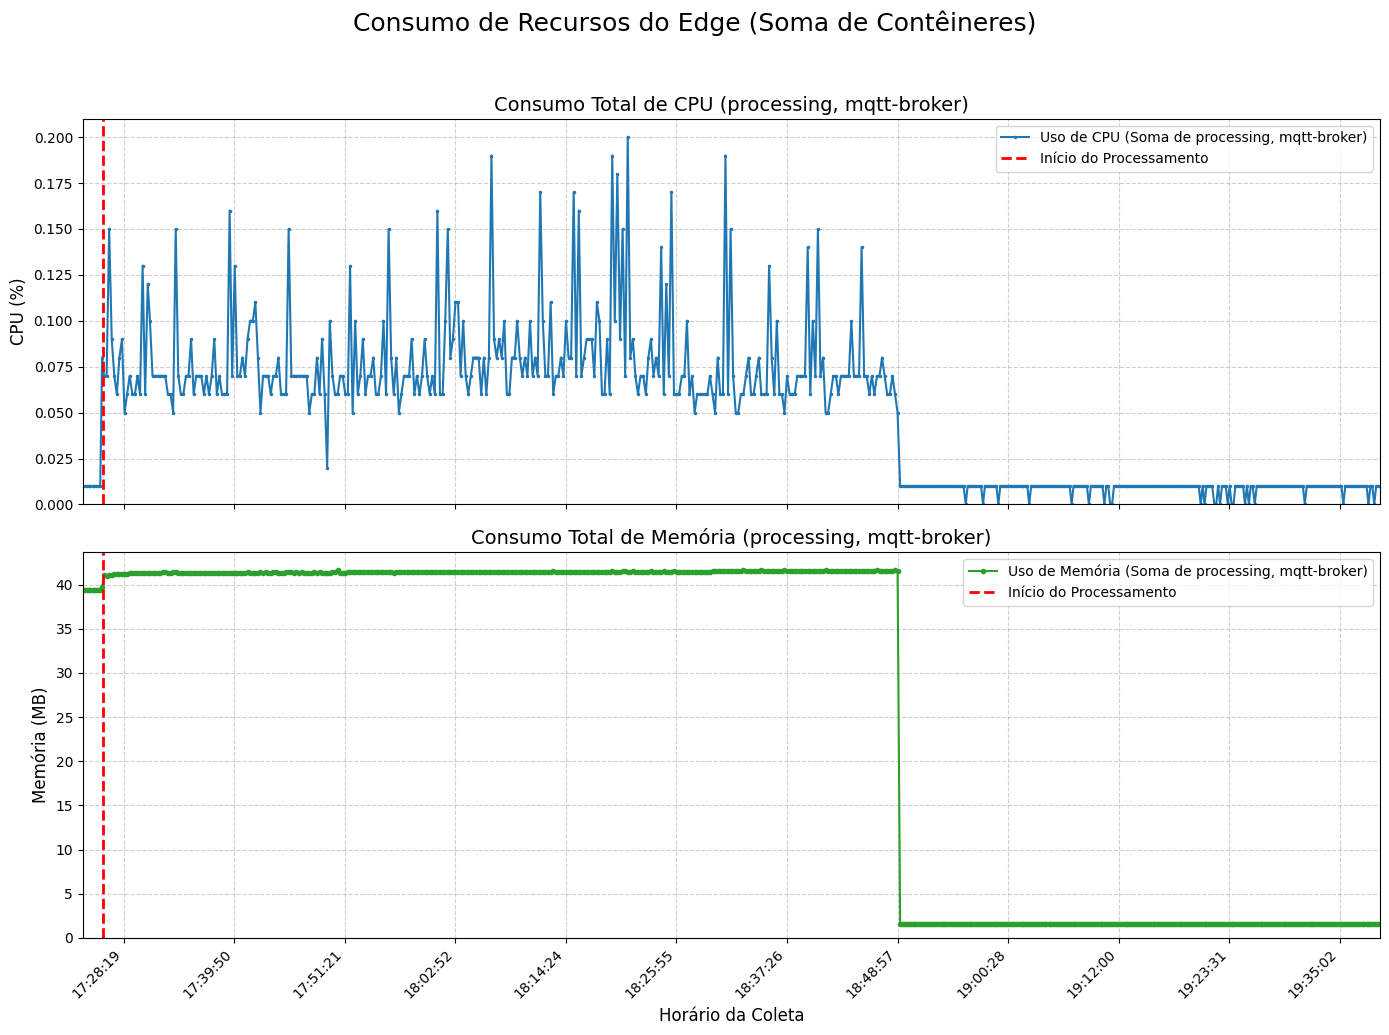

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import sys

# --- Configurações ---
METRICS_CSV_FILE = "metrics.csv"
# (Opcional) Cole aqui o timestamp exato do início do processamento
PROCESSING_START_TIME = "2025-10-23 14:26:10.92097-03:00"

# Lista de contêineres para somar os recursos
CONTAINERS_TO_SUM = ['processing', 'mqtt-broker']
OUTPUT_IMAGE_FILE = "grafico_recursos_edge_combinado.png"

def main():
    try:
        # --- 1. Carregar e Preparar os Dados de Métricas ---
        print(f"Carregando dados de métricas de '{METRICS_CSV_FILE}'...")
        df_metrics = pd.read_csv(METRICS_CSV_FILE)

        # Filtrar apenas os contêineres que queremos somar
        df_filtered = df_metrics[df_metrics['container'].isin(CONTAINERS_TO_SUM)].copy()

        # --- Aviso Importante ---
        found_containers = df_filtered['container'].unique()
        missing_containers = set(CONTAINERS_TO_SUM) - set(found_containers)
        if missing_containers:
            print(f"Aviso: O arquivo CSV não contém dados para: {missing_containers}")
            print(f"O gráfico mostrará a soma apenas dos contêineres encontrados: {found_containers}")

        if df_filtered.empty:
            raise ValueError(f"Nenhum dado encontrado para os contêineres: {CONTAINERS_TO_SUM}")

        # --- 2. A Lógica de Soma (Resampling) ---
        df_filtered['timestamp'] = pd.to_datetime(df_filtered['timestamp'])
        df_filtered = df_filtered.set_index('timestamp')

        # Agrupa os dados em janelas de 1 segundo e SOMA os valores
        df_summed = df_filtered.groupby(pd.Grouper(freq='1s'))[['cpu_percent', 'mem_usage']].sum()

        # Remover quaisquer janelas de 1s onde não houveram dados (ou onde a soma é 0)
        df_summed = df_summed[(df_summed['cpu_percent'] > 0) | (df_summed['mem_usage'] > 0)]
        print("Dados de métricas somados e preparados.")

        # --- 3. Definir o "Momento de Início" e Limites ---
        # *** ALTERAÇÃO REQUISITADA ***
        # O 'start_time' agora é fixo (hardcoded)
        start_time = pd.to_datetime(PROCESSING_START_TIME)
        print(f"Momento de início (fixo) do processamento: {start_time}")

        # Os limites do gráfico ainda são calculados a partir dos dados de métrica
        min_plot_time = df_summed.index.min()
        max_plot_time = df_summed.index.max()

        # --- 4. Criar os Gráficos (2 linhas, 1 coluna) ---
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

        # --- Gráfico 1: Consumo de CPU ---
        ax1.plot(
            df_summed.index,
            df_summed['cpu_percent'],
            marker='.', linestyle='-', markersize=3, color='tab:blue',
            label=f"Uso de CPU (Soma de {', '.join(found_containers)})"
        )
        ax1.axvline(x=start_time, color='red', linestyle='--', linewidth=2, label='Início do Processamento')
        ax1.set_title(f'Consumo Total de CPU ({", ".join(found_containers)})', fontsize=14)
        ax1.set_ylabel('CPU (%)', fontsize=12)
        ax1.set_ylim(bottom=0) # Força o eixo Y a começar em 0
        ax1.grid(True, linestyle='--', alpha=0.6)
        ax1.legend()

        # --- Gráfico 2: Consumo de Memória ---
        ax2.plot(
            df_summed.index,
            df_summed['mem_usage'],
            marker='o', linestyle='-', markersize=3, color='tab:green',
            label=f"Uso de Memória (Soma de {', '.join(found_containers)})"
        )
        ax2.axvline(x=start_time, color='red', linestyle='--', linewidth=2, label='Início do Processamento')
        ax2.set_title(f'Consumo Total de Memória ({", ".join(found_containers)})', fontsize=14)
        ax2.set_ylabel('Memória (MB)', fontsize=12)
        ax2.set_ylim(bottom=0) # Força o eixo Y a começar em 0
        ax2.grid(True, linestyle='--', alpha=0.6)
        ax2.legend()

        # --- 5. Formatar o Eixo X (Compartilhado) ---
        ax2.set_xlabel('Horário da Coleta', fontsize=12)
        ax2.set_xlim(min_plot_time, max_plot_time) # Limita a janela de tempo

        formatter = mdates.DateFormatter('%H:%M:%S')
        ax2.xaxis.set_major_formatter(formatter)
        ax2.xaxis.set_major_locator(ticker.MaxNLocator(nbins=12))

        # Formatação global da figura
        fig.autofmt_xdate(rotation=45)
        fig.suptitle('Consumo de Recursos do Edge (Soma de Contêineres)', fontsize=18, y=1.03)
        plt.tight_layout() # Ajusta para evitar sobreposição

        # 6. Salvar o arquivo
        plt.savefig(OUTPUT_IMAGE_FILE)

        print(f"\nSucesso! O gráfico combinado foi salvo como '{OUTPUT_IMAGE_FILE}'")

    except FileNotFoundError as e:
        print(f"Erro: O arquivo '{METRICS_CSV_FILE}' não foi encontrado. Verifique o nome. {e}")
        sys.exit(1)
    except ValueError as e:
        print(f"Erro nos dados: {e}")
        sys.exit(1)
    except Exception as e:
        print(f"Ocorreu um erro inesperado: {e}")
        sys.exit(1)

if __name__ == "__main__":
    main()